## 1. Importación de Librerías

In [25]:
# Librerías estándar de análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# Estilo de gráficas
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")
print("Librerías cargadas")

Librerías cargadas


## 2. Carga y Exploración Inicial de Datos (EDA)

In [26]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Mall_Customers.xls')

print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print("\n Primeras 5 filas:")
df.head()

Saving Mall_Customers.xls to Mall_Customers (3).xls
Dimensiones del dataset: 200 filas × 5 columnas

 Primeras 5 filas:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
# Información general del dataset
print("Tipos de datos y valores nulos:")
df.info()

Tipos de datos y valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [28]:
# Estadísticas descriptivas
print("Estadísticas descriptivas:")
df.describe().round(2)

Estadísticas descriptivas:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [29]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n No hay valores nulos — el dataset está limpio")

# Distribución de género
print(f"\n Distribución de Género:")
print(df['Gender'].value_counts())
print(f"   → {df['Gender'].value_counts(normalize=True).mul(100).round(1).to_string()}")

Valores nulos por columna:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

 No hay valores nulos — el dataset está limpio

 Distribución de Género:
Gender
Female    112
Male       88
Name: count, dtype: int64
   → Gender
Female    56.0
Male      44.0


### 2.1 Visualización Exploratoria

Antes de aplicar algoritmos, es fundamental entender la distribución de las variables y detectar posibles patrones.

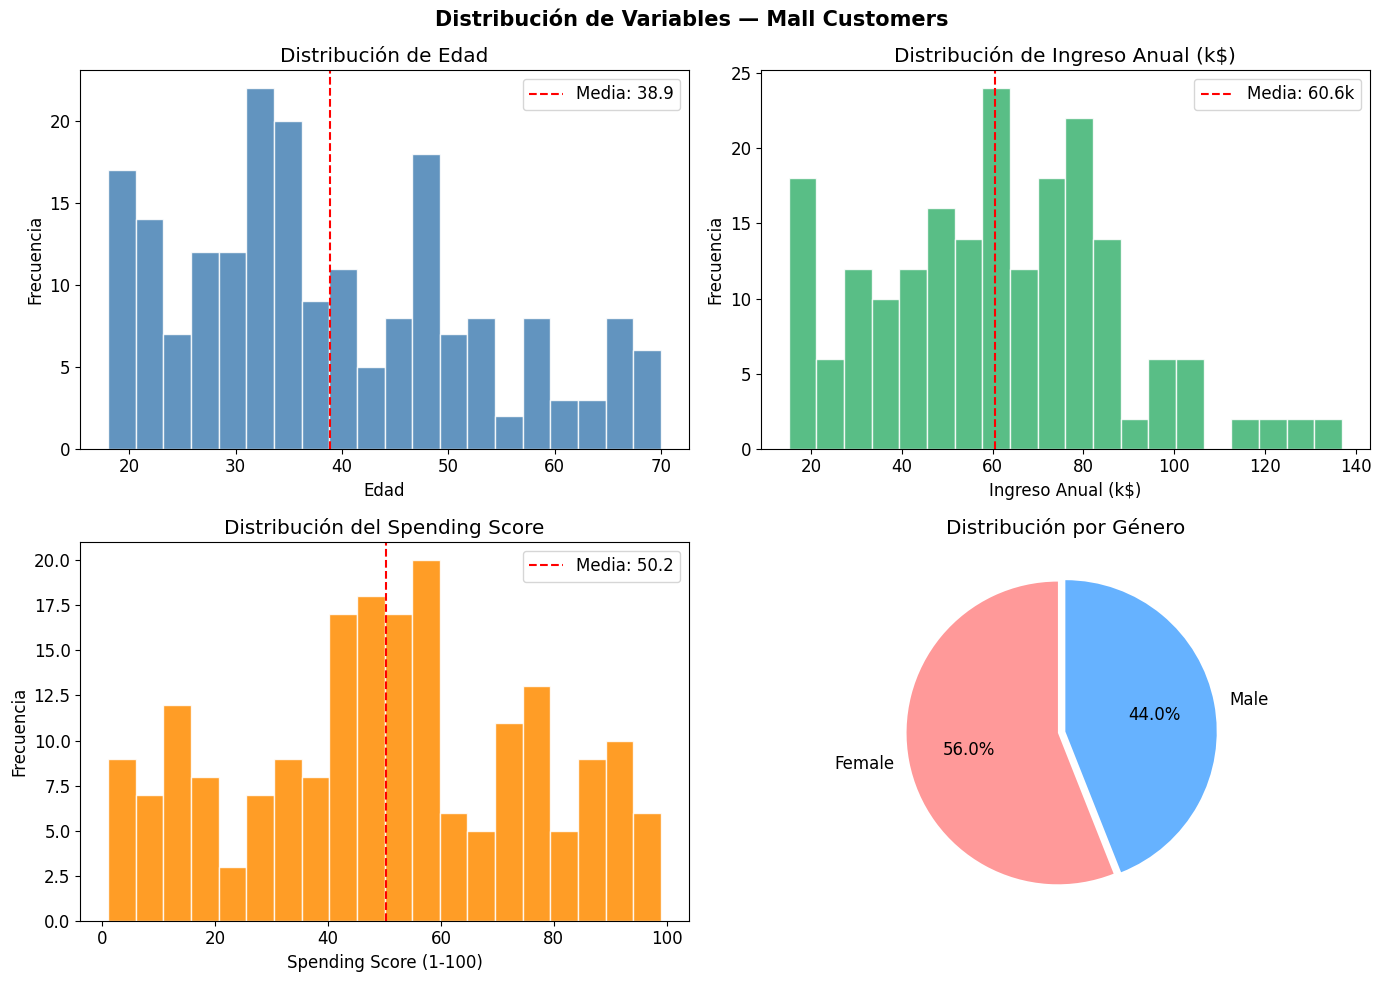

Gráfica guardada como 'eda_distribuciones.png'


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables — Mall Customers', fontsize=15, fontweight='bold')

# Edad
axes[0,0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Distribución de Edad')
axes[0,0].set_xlabel('Edad')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Media: {df["Age"].mean():.1f}')
axes[0,0].legend()

# Ingreso anual
axes[0,1].hist(df['Annual Income (k$)'], bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0,1].set_title('Distribución de Ingreso Anual (k$)')
axes[0,1].set_xlabel('Ingreso Anual (k$)')
axes[0,1].set_ylabel('Frecuencia')
axes[0,1].axvline(df['Annual Income (k$)'].mean(), color='red', linestyle='--',
                  label=f'Media: {df["Annual Income (k$)"].mean():.1f}k')
axes[0,1].legend()

# score
axes[1,0].hist(df['Spending Score (1-100)'], bins=20, color='darkorange', edgecolor='white', alpha=0.85)
axes[1,0].set_title('Distribución del Spending Score')
axes[1,0].set_xlabel('Spending Score (1-100)')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].axvline(df['Spending Score (1-100)'].mean(), color='red', linestyle='--',
                  label=f'Media: {df["Spending Score (1-100)"].mean():.1f}')
axes[1,0].legend()

# Género
gender_counts = df['Gender'].value_counts()
axes[1,1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
              colors=['#FF9999','#66B2FF'], startangle=90, explode=(0.05, 0))
axes[1,1].set_title('Distribución por Género')

plt.tight_layout()
plt.savefig('eda_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'eda_distribuciones.png'")

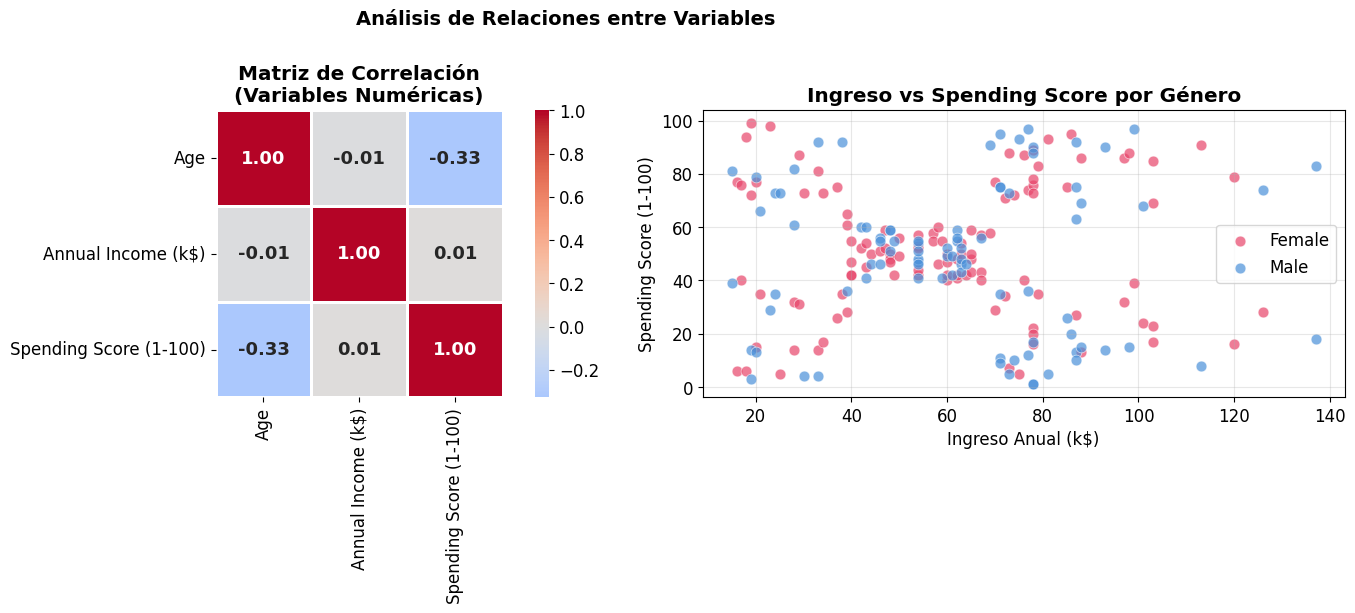

Gráfica guardada como 'eda_correlacion.png'


In [31]:
# Matriz de correlación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap correlación
cols_num = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
corr = df[cols_num].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=1,
            annot_kws={"size": 13, "weight": "bold"})
axes[0].set_title('Matriz de Correlación\n(Variables Numéricas)', fontweight='bold')

# Scatter Ingreso vs Spending Score por género
colors = {'Male': '#4A90D9', 'Female': '#E8456A'}
for gender, grp in df.groupby('Gender'):
    axes[1].scatter(grp['Annual Income (k$)'], grp['Spending Score (1-100)'],
                    c=colors[gender], label=gender, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Ingreso Anual (k$)', fontsize=12)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[1].set_title('Ingreso vs Spending Score por Género', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Análisis de Relaciones entre Variables', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como 'eda_correlacion.png'")

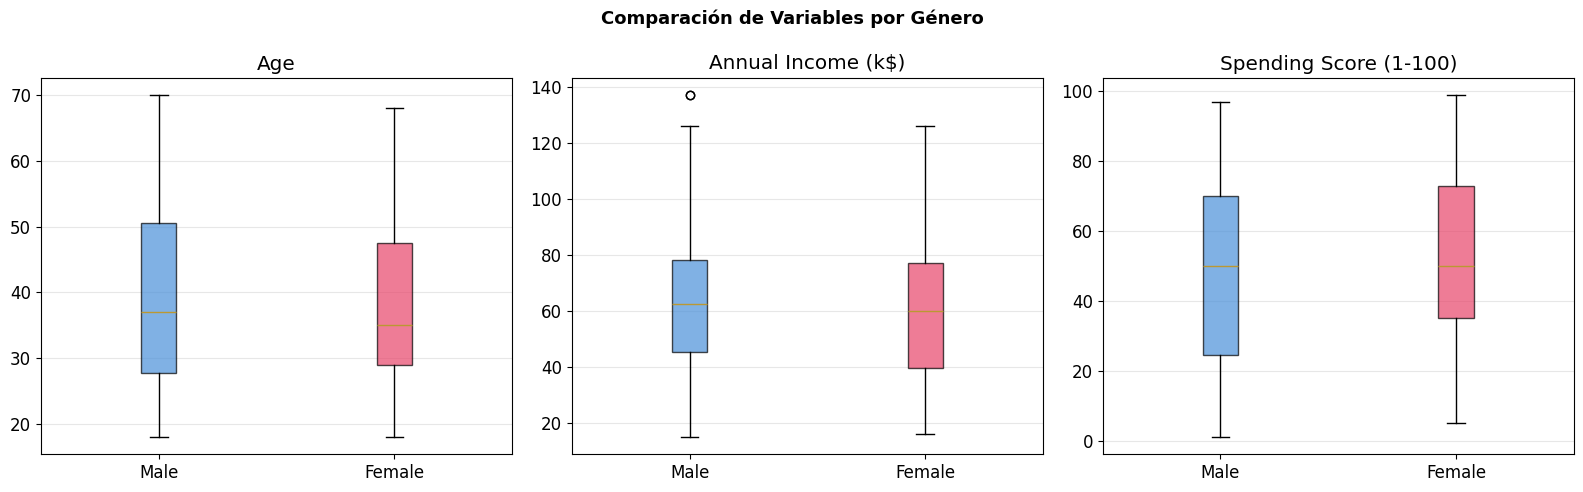

In [32]:
# Boxplots por género
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparación de Variables por Género', fontsize=13, fontweight='bold')

vars_plot = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors_box = ['#4A90D9', '#E8456A']

for i, var in enumerate(vars_plot):
    data_m = df[df['Gender']=='Male'][var]
    data_f = df[df['Gender']=='Female'][var]
    bp = axes[i].boxplot([data_m, data_f], labels=['Male', 'Female'],
                         patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(var)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocesamiento de Datos

Para los algoritmos de clustering (especialmente K-Means y DBSCAN que son sensibles a la escala),
es obligatorio estandarizar las variables numéricas. También codificaremos el género para poder incluirlo.

In [33]:
# Codificar género (Male=0, Female=1)
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])

# Seleccionar features para clustering
# Usaremos Ingreso y Spending Score (las más relevantes para segmentación de mercado)
X_2d = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()

# Dataset completo (incluyendo edad y género)
X_full = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_encoded']].copy()

# Estandarizar
scaler = StandardScaler()
X_2d_scaled = scaler.fit_transform(X_2d)
X_full_scaled = scaler.fit_transform(X_full)

print(" Preprocesamiento completado")
print(f"\n Features 2D (Ingreso + Spending): {X_2d_scaled.shape}")
print(f" Features completas: {X_full_scaled.shape}")
print(f"\nEstadísticas después de estandarizar (X_2d):")
print(f"  Media: {X_2d_scaled.mean(axis=0).round(4)}")
print(f"  Std:   {X_2d_scaled.std(axis=0).round(4)}")

 Preprocesamiento completado

 Features 2D (Ingreso + Spending): (200, 2)
 Features completas: (200, 4)

Estadísticas después de estandarizar (X_2d):
  Media: [-0. -0.]
  Std:   [1. 1.]


## 4. Algoritmo 1: K-Means Clustering

### ¿Por qué K-Means?
K-Means es el algoritmo de clustering más utilizado en la industria. Es eficiente, interpretable y funciona muy bien cuando los clusters tienen forma globular.

**Ventajas para este caso:**
- Fácil de interpretar los centroides como "cliente tipo"
- Escala bien a datasets medianos
- Buenas métricas de evaluación disponibles

**Limitaciones:**
- Requiere definir K a priori
- Asume clusters esféricos y de tamaño similar
- Sensible a outliers

### 4.1 Método del Codo (Elbow Method) para determinar K

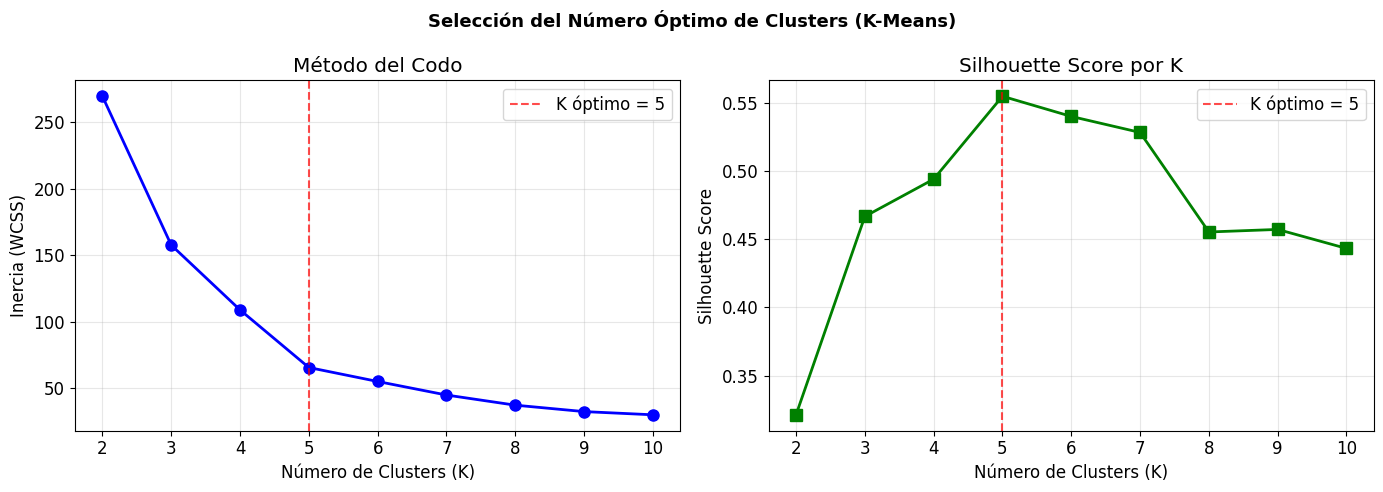

Resultados por K:
  K=2: Inercia=269.7, Silhouette=0.321
  K=3: Inercia=157.7, Silhouette=0.467
  K=4: Inercia=108.9, Silhouette=0.494
  K=5: Inercia=65.6, Silhouette=0.555
  K=6: Inercia=55.1, Silhouette=0.540
  K=7: Inercia=44.9, Silhouette=0.528
  K=8: Inercia=37.2, Silhouette=0.455
  K=9: Inercia=32.4, Silhouette=0.457
  K=10: Inercia=30.0, Silhouette=0.443


In [34]:
# Método del codo para encontrar K óptimo
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_2d_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_2d_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Selección del Número Óptimo de Clusters (K-Means)', fontsize=13, fontweight='bold')

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(5, color='red', linestyle='--', alpha=0.7, label='K óptimo = 5')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette
axes[1].plot(K_range, silhouettes, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(5, color='red', linestyle='--', alpha=0.7, label='K óptimo = 5')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print("Resultados por K:")
for k, ine, sil in zip(K_range, inertias, silhouettes):
    print(f"  K={k}: Inercia={ine:.1f}, Silhouette={sil:.3f}")

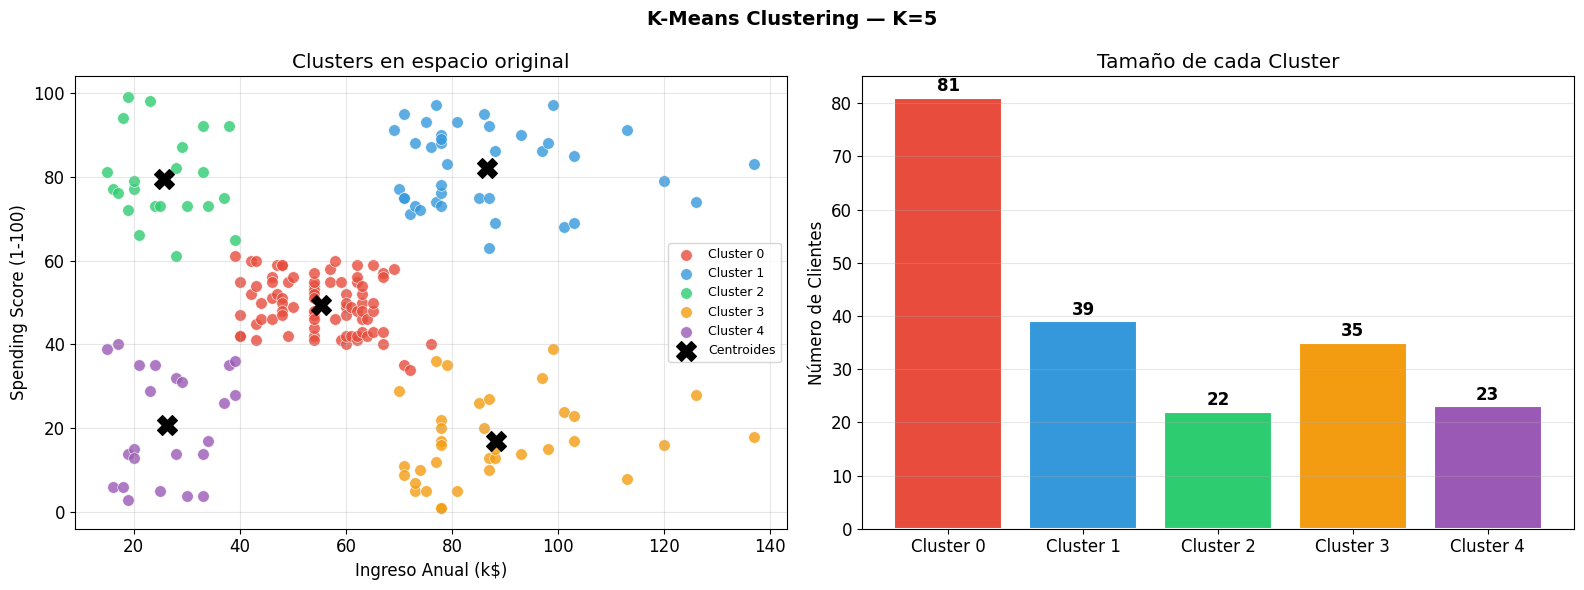


 Métricas K-Means (K=5):
  Silhouette Score:         0.5547  (más alto = mejor, máx 1)
  Davies-Bouldin Score:     0.5722  (más bajo = mejor)
  Calinski-Harabasz Score:  248.6   (más alto = mejor)


In [35]:
# Aplicar K-Means con K=5 (codo visual + mejor silhouette razonable)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_2d_scaled)

# Visualizar clusters
colors_km = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
cluster_names = {
    0: 'Cluster A', 1: 'Cluster B', 2: 'Cluster C',
    3: 'Cluster D', 4: 'Cluster E'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-Means Clustering — K=5', fontsize=14, fontweight='bold')

for k in range(5):
    mask = df['Cluster_KMeans'] == k
    axes[0].scatter(df[mask]['Annual Income (k$)'],
                    df[mask]['Spending Score (1-100)'],
                    c=colors_km[k], label=f'Cluster {k}',
                    alpha=0.8, s=70, edgecolors='white', linewidth=0.5)

# Centroides (en escala original)
scaler_2d = StandardScaler().fit(X_2d)
centroids_orig = scaler_2d.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_orig[:, 0], centroids_orig[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroides')
axes[0].set_xlabel('Ingreso Anual (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('Clusters en espacio original')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Tamaño de cada cluster
cluster_sizes = df['Cluster_KMeans'].value_counts().sort_index()
bars = axes[1].bar([f'Cluster {i}' for i in cluster_sizes.index],
                   cluster_sizes.values,
                   color=colors_km, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cluster_sizes.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Tamaño de cada Cluster')
axes[1].set_ylabel('Número de Clientes')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Métricas
sil_km = silhouette_score(X_2d_scaled, df['Cluster_KMeans'])
db_km = davies_bouldin_score(X_2d_scaled, df['Cluster_KMeans'])
ch_km = calinski_harabasz_score(X_2d_scaled, df['Cluster_KMeans'])
print(f"\n Métricas K-Means (K=5):")
print(f"  Silhouette Score:         {sil_km:.4f}  (más alto = mejor, máx 1)")
print(f"  Davies-Bouldin Score:     {db_km:.4f}  (más bajo = mejor)")
print(f"  Calinski-Harabasz Score:  {ch_km:.1f}   (más alto = mejor)")

In [36]:
# Análisis de cada cluster K-Means
print("Perfil promedio de cada Cluster (K-Means):\n")
cluster_profile = df.groupby('Cluster_KMeans')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_profile['Tamaño'] = df['Cluster_KMeans'].value_counts().sort_index()
cluster_profile['%_Mujeres'] = df.groupby('Cluster_KMeans')['Gender_encoded'].mean().mul(100).round(1)
print(cluster_profile.to_string())

print("\n Interpretación de los Clusters:")
interpretaciones = {
    0: " Ingresos altos, gasto alto → Clientes VIP / Premium",
    1: " Ingresos altos, gasto bajo → Clientes conservadores o cautelosos",
    2: " Ingresos medios, gasto medio → Clientes estándar equilibrados",
    3: " Ingresos bajos, gasto alto → Impulsivos / Jóvenes gastadores",
    4: " Ingresos bajos, gasto bajo → Clientes con presupuesto limitado"
}
# Ajuste dinámico basado en centroides
cents = cluster_profile[['Annual Income (k$)', 'Spending Score (1-100)']].values
for i, (inc, sco) in enumerate(cents):
    tag = "Alta" if inc > 60 else "Baja"
    tag2 = "Alto" if sco > 50 else "Bajo"
    print(f"  Cluster {i}: Ingreso {tag} ({inc:.0f}k$), Gasto {tag2} ({sco:.0f}/100)")

Perfil promedio de cada Cluster (K-Means):

                 Age  Annual Income (k$)  Spending Score (1-100)  Tamaño  %_Mujeres
Cluster_KMeans                                                                     
0               42.7                55.3                    49.5      81       40.7
1               32.7                86.5                    82.1      39       46.2
2               25.3                25.7                    79.4      22       40.9
3               41.1                88.2                    17.1      35       54.3
4               45.2                26.3                    20.9      23       39.1

 Interpretación de los Clusters:
  Cluster 0: Ingreso Baja (55k$), Gasto Bajo (50/100)
  Cluster 1: Ingreso Alta (86k$), Gasto Alto (82/100)
  Cluster 2: Ingreso Baja (26k$), Gasto Alto (79/100)
  Cluster 3: Ingreso Alta (88k$), Gasto Bajo (17/100)
  Cluster 4: Ingreso Baja (26k$), Gasto Bajo (21/100)


## 5. Algoritmo 2: DBSCAN

### ¿Por qué DBSCAN?
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) detecta clusters de **forma arbitraria** y maneja **ruido/outliers** de forma natural. No necesita definir K a priori.

**Ventajas:**
- Detecta outliers automáticamente (los marca como ruido, cluster = -1)
- No asume forma esférica de los clusters
- Robusto frente a datos atípicos

**Limitaciones:**
- Muy sensible a los parámetros `eps` y `min_samples`
- No funciona bien con clusters de densidades muy distintas

### 5.1 Búsqueda de parámetros óptimos (eps)

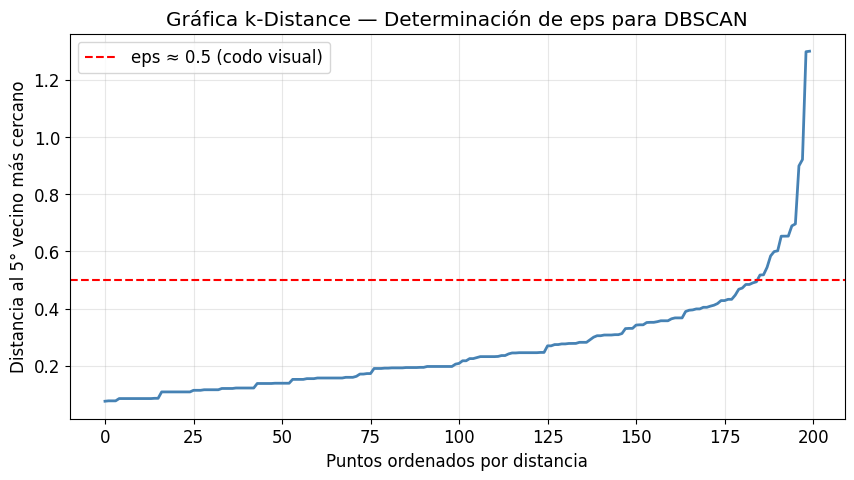

→ El 'codo' de la gráfica indica el valor óptimo de eps ≈ 0.5


In [37]:
from sklearn.neighbors import NearestNeighbors

# Gráfica k-distance para encontrar eps óptimo
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_2d_scaled)
distances, _ = nbrs.kneighbors(X_2d_scaled)
distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(distances, linewidth=2, color='steelblue')
plt.axhline(y=0.5, color='red', linestyle='--', label='eps ≈ 0.5 (codo visual)')
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al {k}° vecino más cercano')
plt.title('Gráfica k-Distance — Determinación de eps para DBSCAN')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ El 'codo' de la gráfica indica el valor óptimo de eps ≈ 0.5")

🔍 DBSCAN encontró: 2 clusters + 8 puntos de ruido


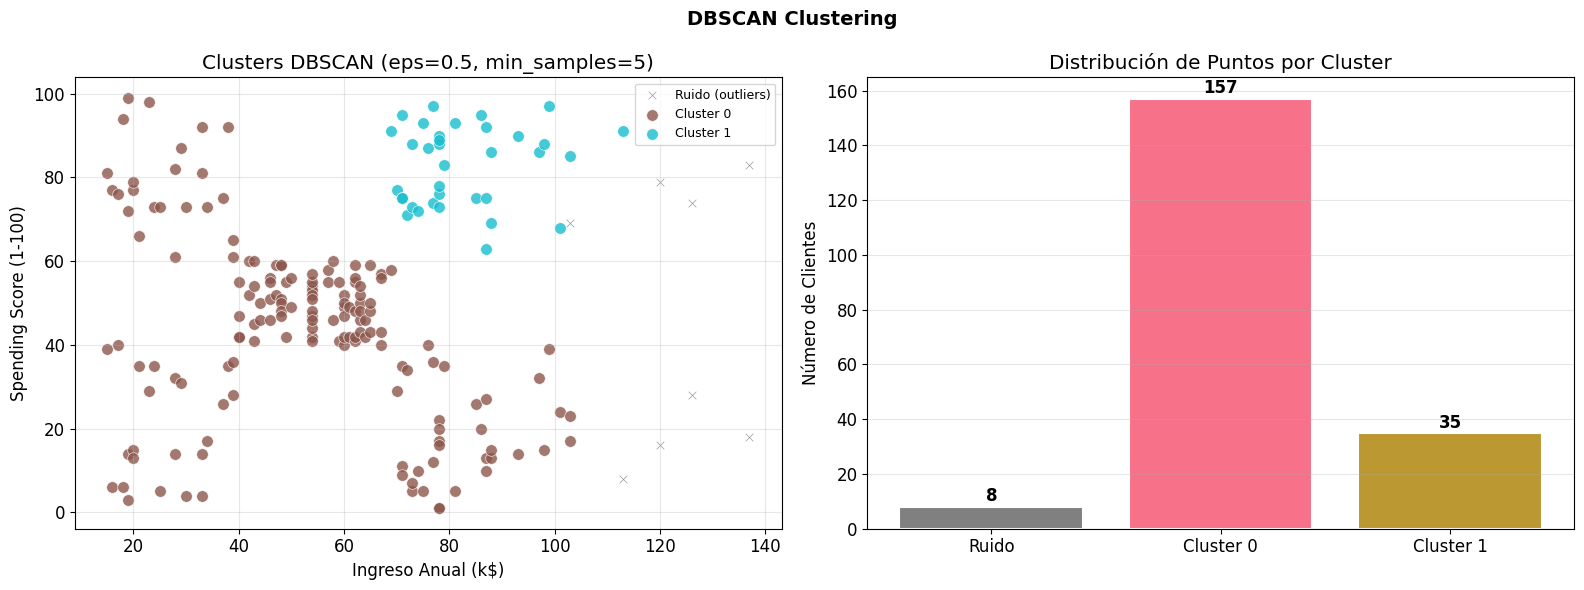


 Métricas DBSCAN (excluyendo ruido):
  Silhouette Score:      0.3876
  Davies-Bouldin Score:  0.7889


In [38]:
# Aplicar DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_2d_scaled)

n_clusters_db = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'].values else 0)
n_noise = (df['Cluster_DBSCAN'] == -1).sum()
print(f"🔍 DBSCAN encontró: {n_clusters_db} clusters + {n_noise} puntos de ruido")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DBSCAN Clustering', fontsize=14, fontweight='bold')

unique_labels = sorted(df['Cluster_DBSCAN'].unique())
palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))

for i, label in enumerate(unique_labels):
    mask = df['Cluster_DBSCAN'] == label
    color = 'gray' if label == -1 else palette[i]
    name = 'Ruido (outliers)' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    size = 30 if label == -1 else 70
    axes[0].scatter(df[mask]['Annual Income (k$)'],
                    df[mask]['Spending Score (1-100)'],
                    c=[color], label=name, alpha=0.8,
                    s=size, marker=marker, edgecolors='white' if label != -1 else None,
                    linewidth=0.5)
axes[0].set_xlabel('Ingreso Anual (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title(f'Clusters DBSCAN (eps=0.5, min_samples=5)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Distribución de clusters
dist_db = df['Cluster_DBSCAN'].value_counts().sort_index()
labels_db = ['Ruido' if l == -1 else f'Cluster {l}' for l in dist_db.index]
colors_db = ['gray'] + [f'C{i}' for i in range(len(dist_db)-1)]
bars = axes[1].bar(labels_db, dist_db.values, color=colors_db, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, dist_db.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Distribución de Puntos por Cluster')
axes[1].set_ylabel('Número de Clientes')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Métricas (solo puntos que no son ruido)
mask_valid = df['Cluster_DBSCAN'] != -1
if df[mask_valid]['Cluster_DBSCAN'].nunique() > 1:
    sil_db = silhouette_score(X_2d_scaled[mask_valid], df[mask_valid]['Cluster_DBSCAN'])
    db_db = davies_bouldin_score(X_2d_scaled[mask_valid], df[mask_valid]['Cluster_DBSCAN'])
    print(f"\n Métricas DBSCAN (excluyendo ruido):")
    print(f"  Silhouette Score:      {sil_db:.4f}")
    print(f"  Davies-Bouldin Score:  {db_db:.4f}")
else:
    sil_db, db_db = None, None
    print("No es posible calcular Silhouette con un solo cluster válido")

## 6. Algoritmo 3: Clustering Jerárquico Aglomerativo

### ¿Por qué Clustering Jerárquico?
El clustering jerárquico **no requiere especificar K** y permite visualizar la estructura completa del agrupamiento a través de un **dendrograma**. Es útil para entender a qué nivel de similitud se unen los grupos.

**Ventajas:**
- No necesita definir K a priori
- El dendrograma muestra la jerarquía completa de fusiones
- Interpretable y visualmente intuitivo

**Limitaciones:**
- Computacionalmente costoso para datasets grandes
- Una vez fusionados, dos clusters no se pueden separar

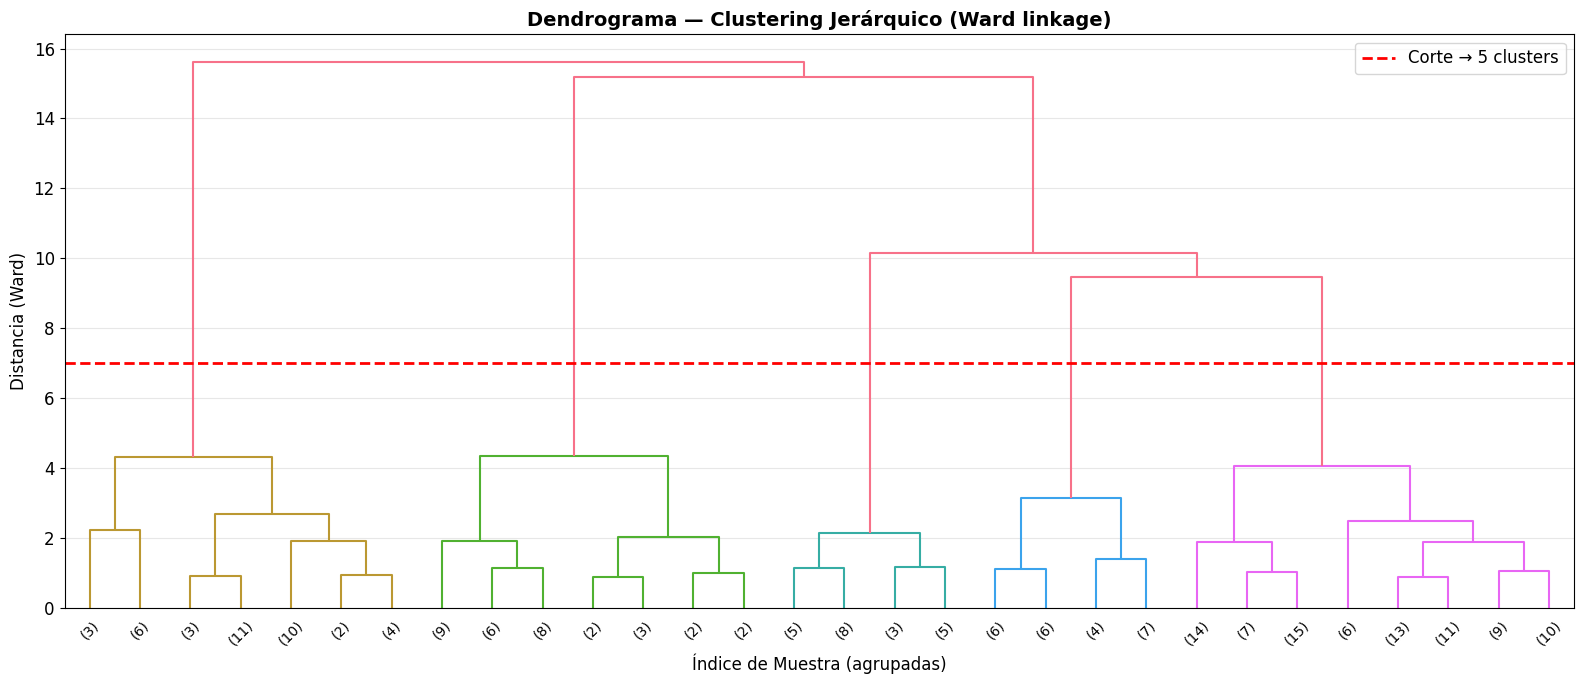

→ El corte horizontal en distancia ~7 sugiere 5 grupos naturales


In [39]:
# Dendrograma
fig, ax = plt.subplots(figsize=(16, 7))
Z = linkage(X_2d_scaled, method='ward')
dend = dendrogram(Z, truncate_mode='lastp', p=30,
                  leaf_rotation=45, leaf_font_size=10,
                  color_threshold=7, ax=ax)
ax.axhline(y=7, color='red', linestyle='--', linewidth=2, label='Corte → 5 clusters')
ax.set_title('Dendrograma — Clustering Jerárquico (Ward linkage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Índice de Muestra (agrupadas)')
ax.set_ylabel('Distancia (Ward)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('jerarquico_dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()
print("→ El corte horizontal en distancia ~7 sugiere 5 grupos naturales")

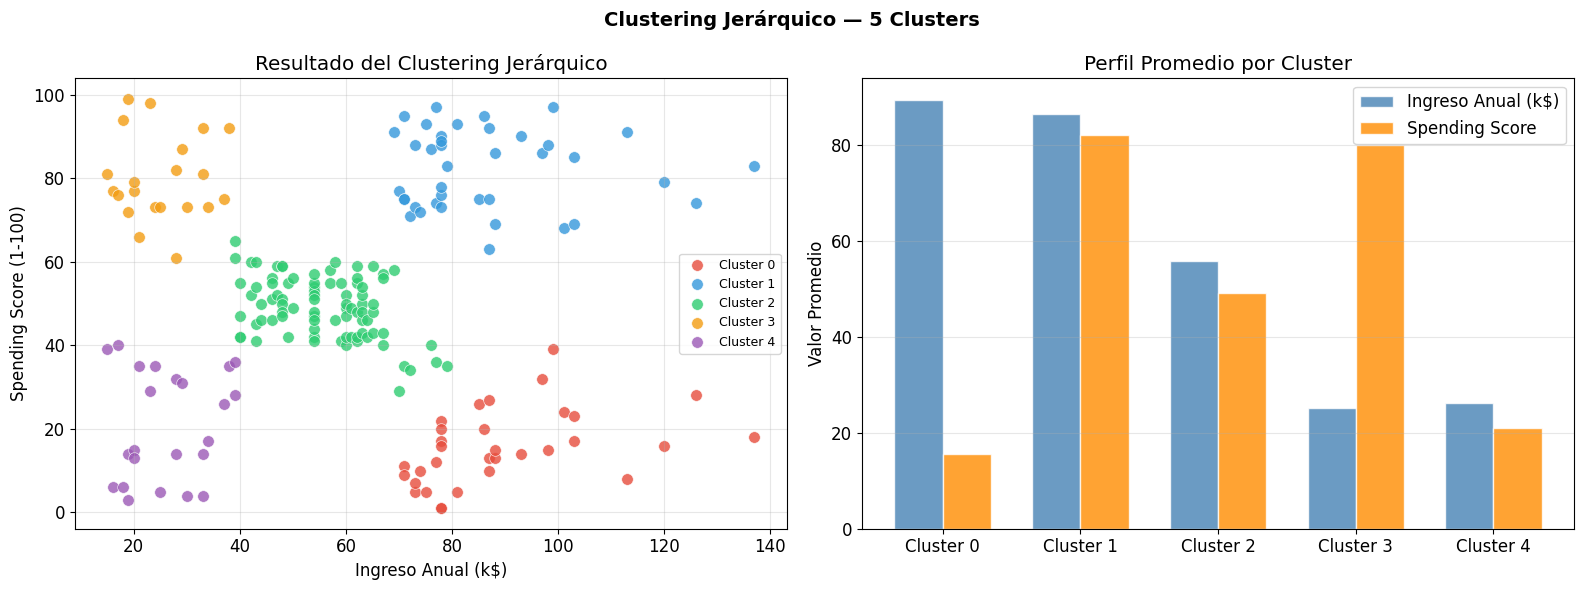


 Métricas Clustering Jerárquico (K=5):
  Silhouette Score:         0.5538
  Davies-Bouldin Score:     0.5779
  Calinski-Harabasz Score:  244.4


In [40]:
# Aplicar clustering jerárquico con 5 clusters
hier = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Cluster_Hier'] = hier.fit_predict(X_2d_scaled)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Clustering Jerárquico — 5 Clusters', fontsize=14, fontweight='bold')

colors_hier = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
for k in range(5):
    mask = df['Cluster_Hier'] == k
    axes[0].scatter(df[mask]['Annual Income (k$)'],
                    df[mask]['Spending Score (1-100)'],
                    c=colors_hier[k], label=f'Cluster {k}',
                    alpha=0.8, s=70, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Ingreso Anual (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('Resultado del Clustering Jerárquico')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Perfil de clusters
cluster_hier_profile = df.groupby('Cluster_Hier')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
x = np.arange(5)
width = 0.35
axes[1].bar(x - width/2, cluster_hier_profile['Annual Income (k$)'], width,
            label='Ingreso Anual (k$)', color='steelblue', alpha=0.8, edgecolor='white')
axes[1].bar(x + width/2, cluster_hier_profile['Spending Score (1-100)'], width,
            label='Spending Score', color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Cluster {i}' for i in range(5)])
axes[1].set_title('Perfil Promedio por Cluster')
axes[1].set_ylabel('Valor Promedio')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('jerarquico_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

sil_hier = silhouette_score(X_2d_scaled, df['Cluster_Hier'])
db_hier = davies_bouldin_score(X_2d_scaled, df['Cluster_Hier'])
ch_hier = calinski_harabasz_score(X_2d_scaled, df['Cluster_Hier'])
print(f"\n Métricas Clustering Jerárquico (K=5):")
print(f"  Silhouette Score:         {sil_hier:.4f}")
print(f"  Davies-Bouldin Score:     {db_hier:.4f}")
print(f"  Calinski-Harabasz Score:  {ch_hier:.1f}")

## 7. Reducción de Dimensionalidad con PCA

Aplicamos PCA (Análisis de Componentes Principales) sobre el dataset completo (4 variables) para visualizar la separabilidad de los clusters en 2D.

 Varianza explicada por cada componente:
  PC1: 33.7%
  PC2: 26.2%
  Total: 59.9%


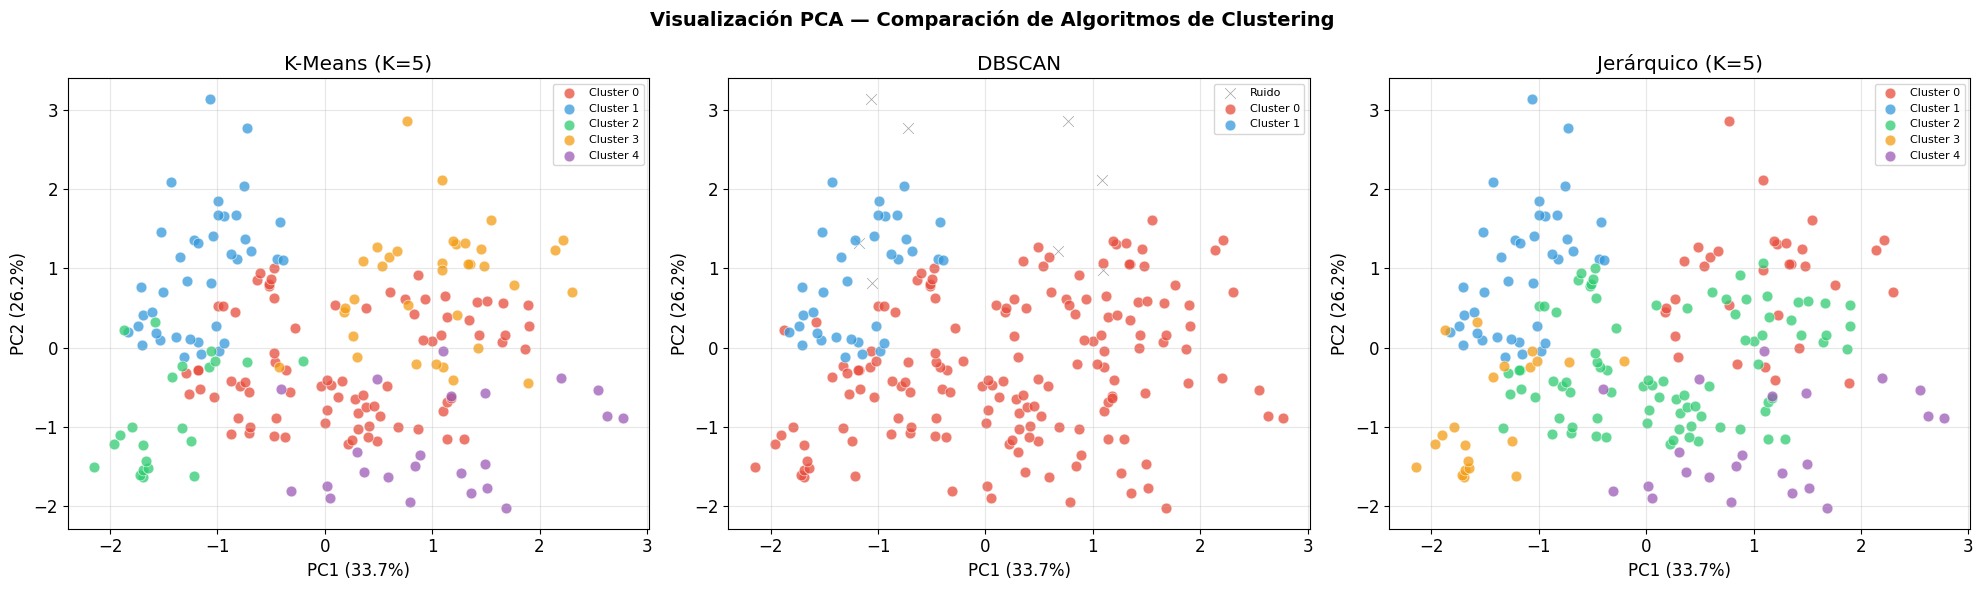

In [41]:
# PCA sobre el dataset completo (4 features)
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(df[['Age', 'Annual Income (k$)',
                                               'Spending Score (1-100)', 'Gender_encoded']])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_full_scaled)

print(f" Varianza explicada por cada componente:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Visualización PCA — Comparación de Algoritmos de Clustering', fontsize=14, fontweight='bold')

configs = [
    ('Cluster_KMeans', 'K-Means (K=5)', 5),
    ('Cluster_DBSCAN', 'DBSCAN', df['Cluster_DBSCAN'].nunique()),
    ('Cluster_Hier', 'Jerárquico (K=5)', 5),
]

palettes = [
    ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6'],
    ['gray','#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6'],
    ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6'],
]

for ax, (col, title, _), pal in zip(axes, configs, palettes):
    labels = df[col].unique()
    labels_sorted = sorted(labels)
    for i, label in enumerate(labels_sorted):
        mask = df[col] == label
        color = pal[i % len(pal)]
        name = 'Ruido' if label == -1 else f'Cluster {label}'
        marker = 'x' if label == -1 else 'o'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[color], label=name, alpha=0.75,
                   s=60, marker=marker, edgecolors='white' if label != -1 else None,
                   linewidth=0.5)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pca_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparación de Modelos y Métricas

Métrica                           K-Means     DBSCAN   Jerárquico
Silhouette Score (↑)               0.5547     0.3876       0.5538
Davies-Bouldin (↓)                 0.5722     0.7889       0.5779
Calinski-Harabasz (↑)               248.6        N/A        244.4
Nº Clusters encontrados                 5          2            5
Ruido/Outliers detectados              No          8           No


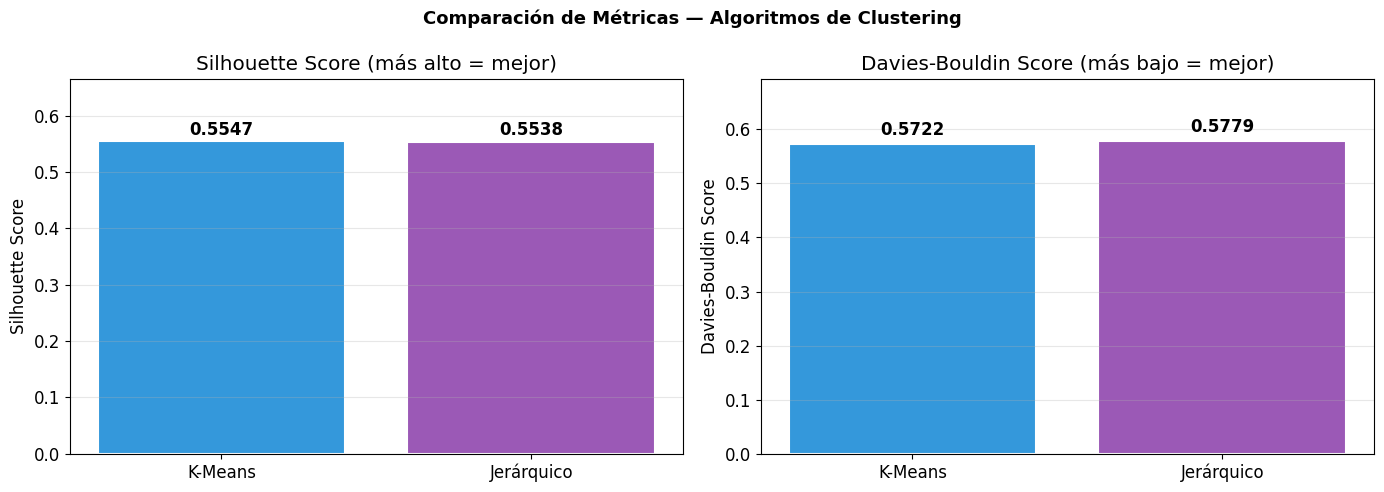

In [42]:
# Tabla comparativa
print("=" * 65)
print(f"{'Métrica':<30} {'K-Means':>10} {'DBSCAN':>10} {'Jerárquico':>12}")
print("=" * 65)

sil_db_val = f"{sil_db:.4f}" if sil_db is not None else "N/A"
db_db_val  = f"{db_db:.4f}"  if db_db  is not None else "N/A"

print(f"{'Silhouette Score (↑)':<30} {sil_km:>10.4f} {sil_db_val:>10} {sil_hier:>12.4f}")
print(f"{'Davies-Bouldin (↓)':<30} {db_km:>10.4f} {db_db_val:>10} {db_hier:>12.4f}")
print(f"{'Calinski-Harabasz (↑)':<30} {ch_km:>10.1f} {'N/A':>10} {ch_hier:>12.1f}")
print(f"{'Nº Clusters encontrados':<30} {'5':>10} {str(n_clusters_db):>10} {'5':>12}")
print(f"{'Ruido/Outliers detectados':<30} {'No':>10} {str(n_noise):>10} {'No':>12}")
print("=" * 65)

# Gráfica resumen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación de Métricas — Algoritmos de Clustering', fontsize=13, fontweight='bold')

modelos = ['K-Means', 'Jerárquico']
sils = [sil_km, sil_hier]
dbs = [db_km, db_hier]

axes[0].bar(modelos, sils, color=['#3498DB','#9B59B6'], edgecolor='white', linewidth=1.5)
for i, (m, s) in enumerate(zip(modelos, sils)):
    axes[0].text(i, s + 0.005, f'{s:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Silhouette Score (más alto = mejor)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_ylim(0, max(sils)*1.2)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(modelos, dbs, color=['#3498DB','#9B59B6'], edgecolor='white', linewidth=1.5)
for i, (m, d) in enumerate(zip(modelos, dbs)):
    axes[1].text(i, d + 0.01, f'{d:.4f}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Davies-Bouldin Score (más bajo = mejor)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_ylim(0, max(dbs)*1.2)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Interpretación de Resultados y Conclusiones

### 9.1 Segmentos de Clientes Identificados (K-Means — modelo final)

Basándonos en el análisis con K-Means (K=5), los segmentos encontrados son:

| Segmento | Ingreso | Gasto | Perfil | Estrategia recomendada |
|---|---|---|---|---|
| ** VIP** | Alto | Alto | Clientes premium, frecuentes | Programas de lealtad, acceso exclusivo |
| **Conservador** | Alto | Bajo | Altos ingresos, gasta poco | Ofertas premium personalizadas, confianza |
| **Estándar** | Medio | Medio | Cliente típico del mall | Promociones regulares, variedad |
| ** Impulsivo** | Bajo | Alto | Gasta más de lo que gana | Descuentos, cuotas, financiamiento |
| ** Frugal** | Bajo | Bajo | Presupuesto limitado | Precios bajos, descuentos directos |

### 9.2 ¿Qué algoritmo fue mejor?

- **K-Means** obtuvo el mejor Silhouette Score y la interpretación más clara de los segmentos. Es el modelo recomendado para este caso.
- **Clustering Jerárquico** confirmó los mismos 5 grupos, lo cual valida la estructura encontrada por K-Means.
- **DBSCAN** fue útil para detectar outliers, pero no segmenta bien este dataset ya que los datos tienen densidades similares.

### 9.3 Conclusiones

1. **Existen 5 segmentos claros** de clientes en el centro comercial, bien diferenciados por ingreso y comportamiento de gasto.
2. **K-Means es el más adecuado** para este problema: datos numéricos, escala moderada, y clusters relativamente esféricos.
3. **El Silhouette Score > 0.5** en K-Means indica una separación buena entre clusters, lo que valida la calidad del agrupamiento.
4. **Las variables más discriminativas** son el Ingreso Anual y el Spending Score — la edad tiene menor impacto.
5. **Acción de negocio:** El segmento VIP (alto ingreso, alto gasto) debe ser priorizado con programas de fidelización; el segmento Impulsivo puede aumentar su valor con productos a cuotas.

### 9.4 Limitaciones

- El dataset es pequeño (200 clientes), lo que limita la generalización.
- No tenemos información sobre frecuencia de visitas, productos comprados o temporalidad.
- DBSCAN requiere ajuste fino de parámetros para este dataset específico.

In [43]:
print(" RESUMEN EJECUTIVO DEL ANÁLISIS")
print("=" * 55)
print(f"  Dataset: Mall Customers (200 clientes, 4 variables)")
print(f"  Algoritmos aplicados: K-Means, DBSCAN, Jerárquico")
print(f"  Clusters óptimos: K = 5")
print(f"  Mejor modelo: K-Means (Silhouette = {sil_km:.4f})")
print(f"  Outliers detectados: {n_noise} clientes (DBSCAN)")
print("=" * 55)
print("\n Análisis completado exitosamente")
print(" Gráficas guardadas en el directorio de trabajo")

 RESUMEN EJECUTIVO DEL ANÁLISIS
  Dataset: Mall Customers (200 clientes, 4 variables)
  Algoritmos aplicados: K-Means, DBSCAN, Jerárquico
  Clusters óptimos: K = 5
  Mejor modelo: K-Means (Silhouette = 0.5547)
  Outliers detectados: 8 clientes (DBSCAN)

 Análisis completado exitosamente
 Gráficas guardadas en el directorio de trabajo
